In [204]:
import nifty.re as jft
import jax.random as random
import jax
import jax.numpy as jnp
import numpy as np
# from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import seaborn as sns

In [205]:
# enable float64 precision
jax.config.update("jax_enable_x64", True)


# initialize JAX random key
seed = 42
key = random.PRNGKey(seed)

In [206]:
# measurement locations and data
t = np.load("data/time.npy")
d = np.load("data/true_trace.npy")
# d /=20

In [207]:
def inv_cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.inv(jax.scipy.linalg.toeplitz(cov0))

In [208]:
def inv_std(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    Cov = jax.scipy.linalg.toeplitz(cov0)
    L = jax.scipy.linalg.cholesky(Cov)
    return jax.scipy.linalg.inv(L)

# No noise

In [209]:
# models for a and b
a = jft.LogNormalPrior(mean=4, std=3, name="a_input")
# b = jft.NormalPrior(mean=0, std=3, name="b_input")


# linear regression model
class LinearModel(jft.Model):
    def __init__(self, x, a):
        self.x = x
        super().__init__(domain=a.domain, white_init=True)

    def __call__(self, inp):
        return self.x
    


my_model = LinearModel(d, a)


# likelihood
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03
Inv_Cov = inv_cov(len(d), A, omega0, gamma, p, C)
Inv_Std = inv_std(len(d), A, omega0, gamma, p, C)

noise_cov_inv = lambda x: jnp.matmul(Inv_Cov, x)
noise_std_inv = lambda x: jnp.matmul(Inv_Std, x)
# 2. FIX: Create an explicit class that JAX can transpose cleanly
# class CorrelatedInverseNoise:
#     def __init__(self, mat):
#         self.mat = mat

#     def __call__(self, x):
#         # Forward matrix-vector multiplication
#         return jnp.matmul(self.mat, x)

#     def transpose(self, x):
#         # Adjoint/Transpose multiplication required by NIFTy's CG solver
#         return jnp.matmul(self.mat.T, x)
# noise_cov_inv_op = CorrelatedInverseNoise(Inv_Cov)

lh = jft.Gaussian(data=d, noise_cov_inv=noise_cov_inv, noise_std_inv=noise_std_inv).amend(my_model)

In [210]:
# cov1 = lh.noise_cov_inv(jft.random_like(subkey, lh.domain))
# cov2 = noise_cov_inv(jft.random_like(subkey, lh.domain))

# plt.plot(cov1)
# plt.plot(cov2)

In [211]:
key, subkey = random.split(key, 2)
init_pos = lh.init(subkey)
print("initial position: ", init_pos)
init_pos = jft.Vector(init_pos)
print("initial position vector: ", init_pos)

n_vi_iterations = 6
n_samples = 4
key, sampling_key = random.split(key, 2)

draw_linear_kwargs = dict(
    cg_name=None,
    cg_kwargs=dict(absdelta=1e-5 * jft.size(lh.domain), maxiter=100),
)

kl_kwargs = dict(minimize_kwargs=dict(name=None, xtol=1e-4, maxiter=35))

sample_mode = "linear_resample"

optimize_kl_args = dict(
    likelihood=lh,
    position_or_samples=init_pos,
    n_total_iterations=n_vi_iterations,
    n_samples=n_samples,
    key=sampling_key,
    draw_linear_kwargs=draw_linear_kwargs,
    kl_kwargs=kl_kwargs,
    sample_mode=sample_mode,
)

initial position:  {'a_input': Array(-0.44370261, dtype=float64)}
initial position vector:  Vector({'a_input': Array(-0.44370261, dtype=float64)})


In [212]:
samples, state = jft.optimize_kl(**optimize_kl_args)

OPTIMIZE_KL: Starting 0001
CG: gamma=0, converged!
OPTIMIZE_KL: Iteration 0001 E:+1.4511e-01
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 2
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     0.0±     0.0, avg:     +0.0±     0.0, #dof:    100'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:    0.29±    0.37, avg:     +0.0±    0.54, #dof:      1'


OPTIMIZE_KL: Starting 0002
OPTIMIZE_KL: Iteration 0002 E:+5.8357e-01
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     0.0±     0.0, avg:     +0.0±     0.0, #dof:    100'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:     1.2±     1.7, avg:     +0.0±     1.1, #dof:      1'


OPTIMIZE_KL: Starting 0003
OPTIMIZE_KL: Iteration 0003 E:+1.5797e-01
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelih

In [213]:
y_samples = tuple(my_model(s) for s in samples)
y_mean = jft.mean(y_samples)

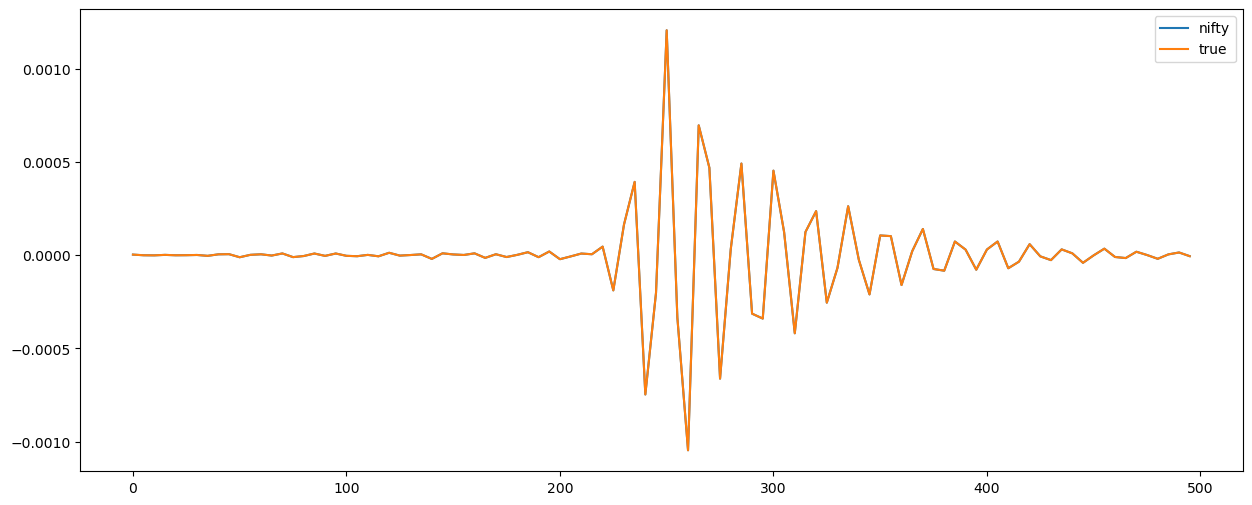

In [214]:
plt.figure(figsize=(15,6))
plt.plot(t, y_mean, label="nifty")
plt.plot(t, d, label="true")
plt.legend()
plt.show()

In [215]:
def compare_plot(y_mean, x=t, y_true=d):

    # calculate statistical measurements
    diff = y_mean - y_true
    rmse = np.sqrt(np.mean(diff**2)) #Root mean square

    # plot
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # vertical lines
    for j in range(2):
         for i in range(len(x)):
            axes[j].axvline(i*5, c="lightgray", linestyle="--")

    # first plot
    axes[0].plot(x, y_true, label=f"True")
    axes[0].plot(x, y_mean, label=f"nifty mean")
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray")
    axes[1].plot(x, diff, label=f"RMSE = {rmse:.2f}")

    axes[1].set_ylabel(r"Residual")
    axes[1].legend()
    plt.xlabel(r"$t$ [ns]")

    plt.show()

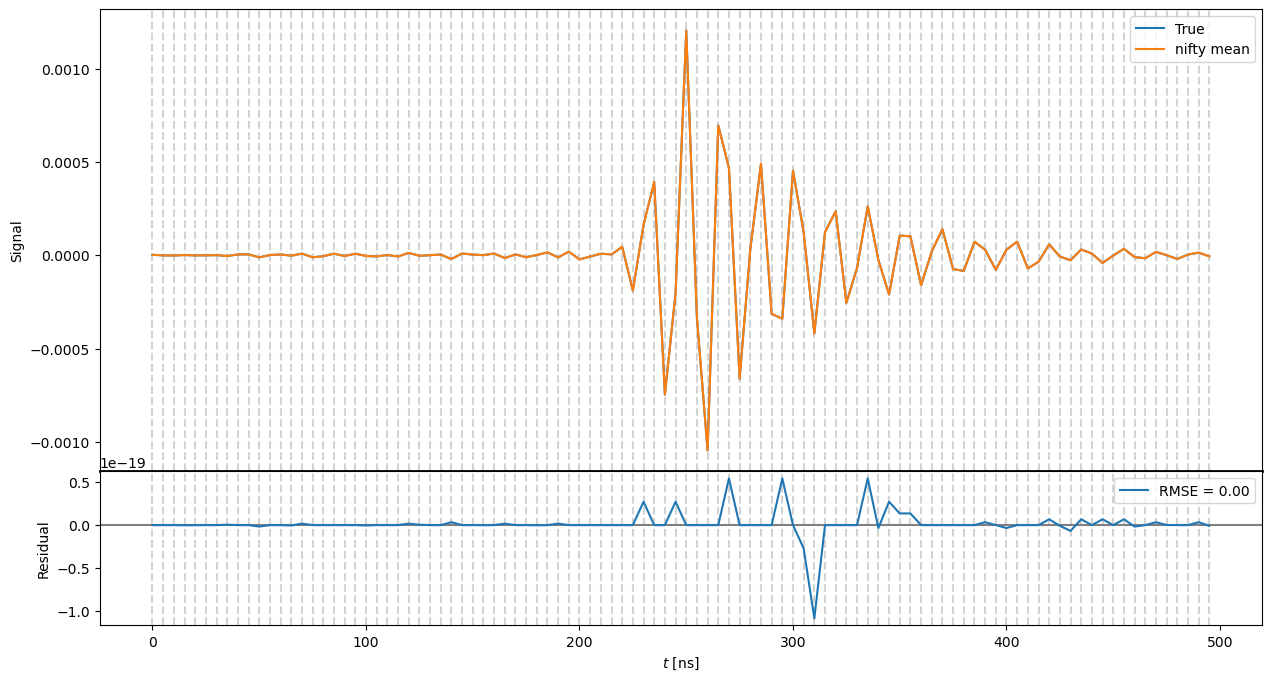

In [216]:
compare_plot(y_mean)

# With noise from Cov

In [217]:
def cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.toeplitz(cov0)

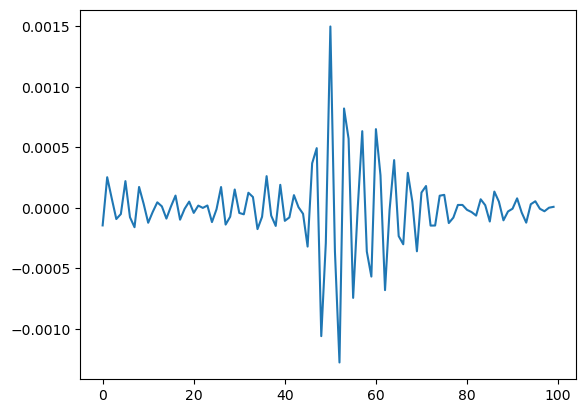

In [218]:
Cov = cov(len(d), A, omega0, gamma, p, C)

key, subkey = random.split(key, 2)

distribution = jft.NormalPrior(mean=0, std=1, shape=(len(d),), name="input")

xi = jft.random_like(subkey, distribution.domain)

L = jax.scipy.linalg.cholesky(Cov)
n = L @ xi["input"]

d_covnoise = d+n

plt.plot(d_covnoise)


In [219]:
lh_covnoise = jft.Gaussian(data=d_covnoise, noise_cov_inv=noise_cov_inv, noise_std_inv = noise_std_inv).amend(my_model)

key, subkey = random.split(key, 2)
init_pos = lh.init(subkey)
print("initial position: ", init_pos)
init_pos = jft.Vector(init_pos)
print("initial position vector: ", init_pos)

n_vi_iterations = 6
n_samples = 4
key, sampling_key = random.split(key, 2)

optimize_kl_args = dict(
    likelihood=lh_covnoise,
    position_or_samples=init_pos,
    n_total_iterations=n_vi_iterations,
    n_samples=n_samples,
    key=sampling_key,
    draw_linear_kwargs=draw_linear_kwargs,
    kl_kwargs=kl_kwargs,
    sample_mode=sample_mode,
)

s_covnoise, state_covnoise = jft.optimize_kl(**optimize_kl_args)

OPTIMIZE_KL: Starting 0001
CG: gamma=0, converged!
OPTIMIZE_KL: Iteration 0001 E:+4.9598e+01
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 2
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.86± 1.1e-16, avg:    -0.16±     0.0, #dof:    100'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:    0.96±    0.72, avg:     +0.0±    0.98, #dof:      1'


OPTIMIZE_KL: Starting 0002
OPTIMIZE_KL: Iteration 0002 E:+4.9705e+01
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.86± 1.1e-16, avg:    -0.16±     0.0, #dof:    100'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:     1.2±     1.1, avg:     +0.0±     1.1, #dof:      1'


OPTIMIZE_KL: Starting 0003
OPTIMIZE_KL: Iteration 0003 E:+4.9324e+01
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelih

initial position:  {'a_input': Array(0.65998258, dtype=float64)}
initial position vector:  Vector({'a_input': Array(0.65998258, dtype=float64)})


OPTIMIZE_KL: Iteration 0006 E:+4.9511e+01
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.86± 1.1e-16, avg:    -0.16±     0.0, #dof:    100'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:    0.78±     1.2, avg:     +0.0±    0.88, #dof:      1'




In [220]:
y_covnoise = tuple(my_model(s) for s in s_covnoise)
covnoise_mean = jft.mean(y_covnoise)

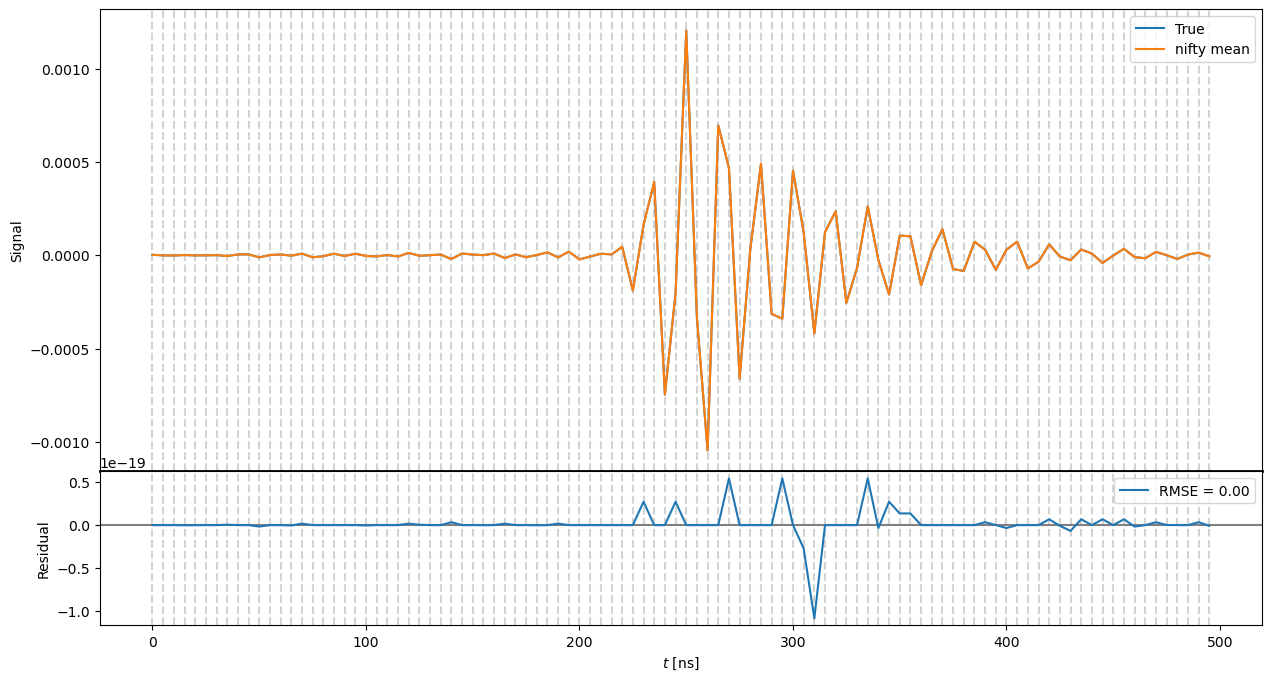

In [222]:
compare_plot(covnoise_mean)

# check diagonal
## ND-Noise by Diag-Cov

In [223]:
Inv_Cov_diag = np.diag(np.diag(Inv_Cov))
Inv_Std_diag = np.diag(np.diag(Inv_Std))

noise_cov_inv_diag = lambda x: jnp.matmul(Inv_Cov_diag, x)
noise_std_inv_diag = lambda x: jnp.matmul(Inv_Std_diag, x)

lh_covnoise_diag = jft.Gaussian(data=d_covnoise, noise_cov_inv=noise_cov_inv_diag, noise_std_inv=noise_std_inv_diag).amend(my_model)

key, subkey = random.split(key, 2)
init_pos = lh.init(subkey)
print("initial position: ", init_pos)
init_pos = jft.Vector(init_pos)
print("initial position vector: ", init_pos)

n_vi_iterations = 6
n_samples = 4
key, sampling_key = random.split(key, 2)

optimize_kl_args = dict(
    likelihood=lh_covnoise_diag,
    position_or_samples=init_pos,
    n_total_iterations=n_vi_iterations,
    n_samples=n_samples,
    key=sampling_key,
    draw_linear_kwargs=draw_linear_kwargs,
    kl_kwargs=kl_kwargs,
    sample_mode=sample_mode,
)

s_covnoise_diag, state_covnoise_diag = jft.optimize_kl(**optimize_kl_args)

OPTIMIZE_KL: Starting 0001
CG: gamma=0, converged!
OPTIMIZE_KL: Iteration 0001 E:+1.0635e+03
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 2
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     4.2± 8.9e-16, avg:   -0.099± 1.4e-17, #dof:    100'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:     2.0±     2.5, avg:     +0.0±     1.4, #dof:      1'




initial position:  {'a_input': Array(0.28574771, dtype=float64)}
initial position vector:  Vector({'a_input': Array(0.28574771, dtype=float64)})


OPTIMIZE_KL: Starting 0002
OPTIMIZE_KL: Iteration 0002 E:+1.0632e+03
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     4.2± 8.9e-16, avg:   -0.099± 1.4e-17, #dof:    100'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:     1.3±     0.7, avg:     +0.0±     1.1, #dof:      1'


OPTIMIZE_KL: Starting 0003
CG: gamma=0, converged!
OPTIMIZE_KL: Iteration 0003 E:+1.0629e+03
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     4.2± 8.9e-16, avg:   -0.099± 1.4e-17, #dof:    100'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:    0.81±     1.3, avg:     +0.0±     0.9, #dof:      1'


OPTIMIZE_KL: Starting 0004
CG: gamma=0, converged!
OPTIMIZE_KL: Iteration 0004 E:+1.0627e+03
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps

In [224]:
y_covnoise_diag = tuple(my_model(s) for s in s_covnoise_diag)
covnoise_diag_mean = jft.mean(y_covnoise_diag)

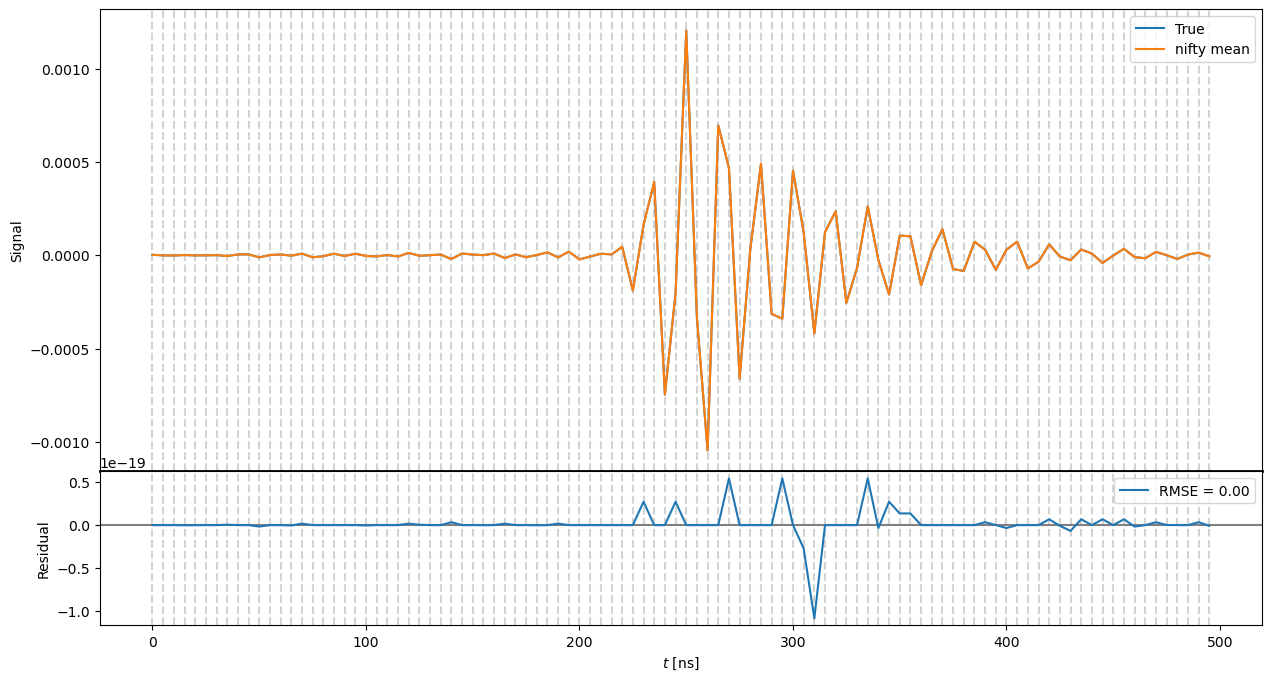

In [225]:
compare_plot(covnoise_diag_mean)

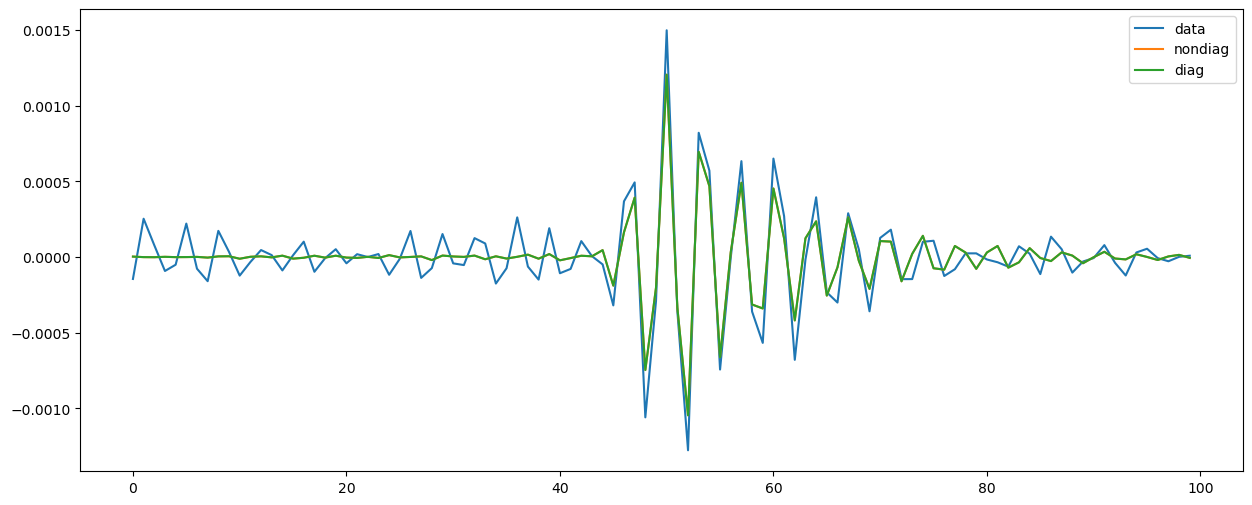

In [226]:
plt.figure(figsize=(15,6))
plt.plot(d_covnoise, label="data")
plt.plot(covnoise_mean, label="nondiag")
plt.plot(covnoise_diag_mean, label="diag")

plt.legend()
plt.show()

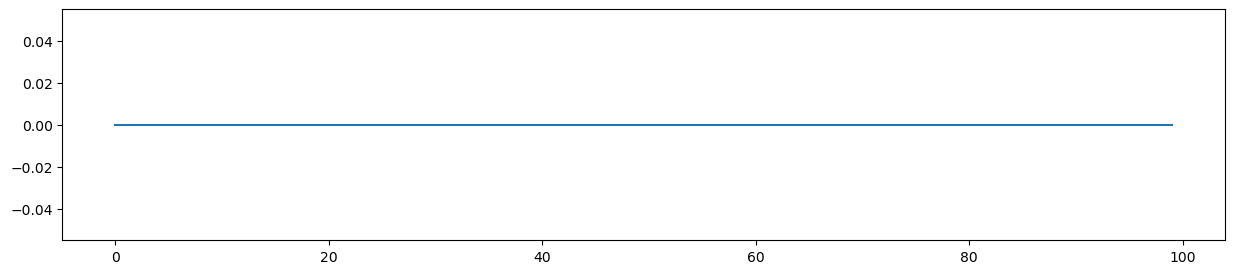

In [227]:
plt.figure(figsize=(15,3))
plt.plot(covnoise_diag_mean-covnoise_mean)
plt.show()

## Diag-Noise by Diag-Cov

In [228]:
Cov = cov(len(d), A, omega0, gamma, p, C)

distribution = jft.NormalPrior(mean=0, std=1, shape=(len(d),), name="input")

xi = jft.random_like(subkey, distribution.domain)

n = np.sqrt(np.diag(Cov)) * xi["input"]

d_covnoise_diag = d+n

In [229]:
L = jax.scipy.linalg.cholesky(Cov)
n = L @ xi["input"]

d_covnoise = d+n


In [231]:
lh_covnoise_diag_diag = jft.Gaussian(data=d_covnoise_diag, noise_cov_inv=noise_cov_inv_diag).amend(my_model)

optimize_kl_args = dict(
    likelihood=lh_covnoise_diag_diag,
    position_or_samples=init_pos,
    n_total_iterations=n_vi_iterations,
    n_samples=n_samples,
    key=sampling_key,
    draw_linear_kwargs=draw_linear_kwargs,
    kl_kwargs=kl_kwargs,
    sample_mode=sample_mode,
)

s_covnoise_diag_diag, state_covnoise_diag_diag = jft.optimize_kl(**optimize_kl_args)

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`
OPTIMIZE_KL: Starting 0001
CG: gamma=0, converged!
OPTIMIZE_KL: Iteration 0001 E:+1.9216e+03
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 2
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²: 3.8e+01±     0.0, avg:   +0.015±     0.0, #dof:    100'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:     2.0±     2.5, avg:     +0.0±     1.4, #dof:      1'


OPTIMIZE_KL: Starting 0002
OPTIMIZE_KL: Iteration 0002 E:+1.9212e+03
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²: 3.8e+01±     0.0, avg:   +0.015±     0.0, #dof:    100'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:     1.3±     0.7, avg:     +0.0±     1.1, #dof:      1'


OPTIMIZE_KL: Starting 0003
CG: gamma=0, converged!
OPTIMIZE_KL: Iteration 0003 E:+1.92

In [232]:
y_covnoise_diag_diag = tuple(my_model(s) for s in s_covnoise_diag_diag)
covnoise_diag_diag_mean = jft.mean(y_covnoise_diag_diag)

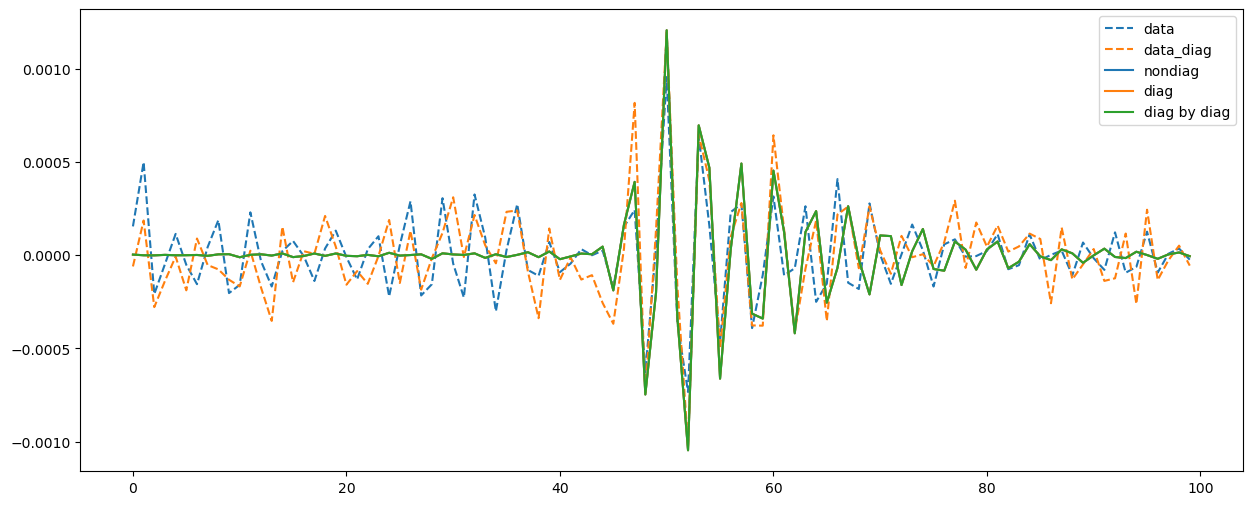

In [233]:
plt.figure(figsize=(15,6))
plt.plot(d_covnoise, label="data", c="tab:blue", linestyle="--")
plt.plot(d_covnoise_diag, label="data_diag", c="tab:orange", linestyle="--")
plt.plot(covnoise_mean, label="nondiag", c="tab:blue")
plt.plot(covnoise_diag_mean, label="diag", c="tab:orange")
plt.plot(covnoise_diag_diag_mean, label="diag by diag", c="tab:green")

plt.legend()
plt.show()

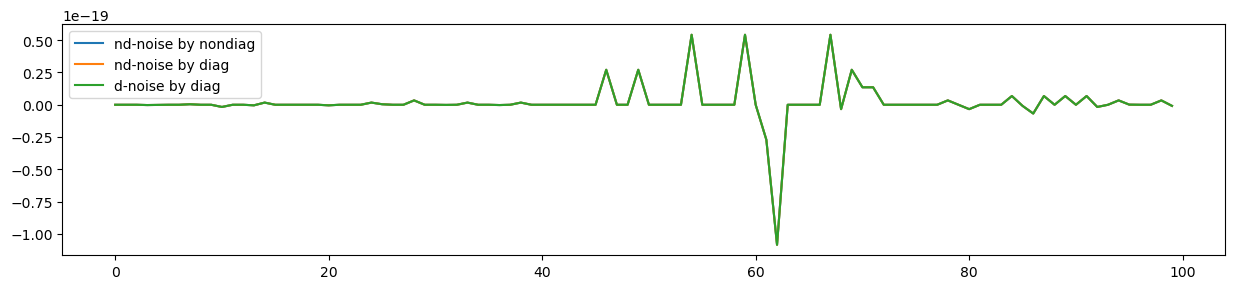

In [234]:
plt.figure(figsize=(15, 3))
plt.plot(covnoise_mean-d, label="nd-noise by nondiag")
plt.plot(covnoise_diag_mean-d, label="nd-noise by diag")
plt.plot(covnoise_diag_diag_mean-d, label="d-noise by diag")
plt.legend()
plt.show()

# Size 200

In [ ]:
# measurement locations and data
t = np.load("data/time.npy")
d = np.load("data/true_trace.npy")

In [ ]:
# models for a and b
a = jft.LogNormalPrior(mean=4, std=3, name="a_input")
# b = jft.NormalPrior(mean=0, std=3, name="b_input")


# linear regression model
class LinearModel(jft.Model):
    def __init__(self, x, a):
        self.x = x
        super().__init__(domain=a.domain, white_init=True)

    def __call__(self, inp):
        return self.x

my_model = LinearModel(d, a)

# likelihood
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03
Inv_Cov = inv_cov(len(d), A, omega0, gamma, p, C)
Inv_Std = inv_std(len(d), A, omega0, gamma, p, C)

noise_cov_inv = lambda x: jnp.matmul(Inv_Cov, x)
noise_std_inv = lambda x: jnp.matmul(Inv_Std, x)


lh = jft.Gaussian(data=d, noise_cov_inv=noise_cov_inv, noise_std_inv=noise_std_inv).amend(my_model)

In [ ]:
key, subkey = random.split(key, 2)
init_pos = lh.init(subkey)
print("initial position: ", init_pos)
init_pos = jft.Vector(init_pos)
print("initial position vector: ", init_pos)

n_vi_iterations = 6
n_samples = 4
key, sampling_key = random.split(key, 2)

draw_linear_kwargs = dict(
    cg_name=None,
    cg_kwargs=dict(absdelta=1e-5 * jft.size(lh.domain), maxiter=100),
)

kl_kwargs = dict(minimize_kwargs=dict(name=None, xtol=1e-4, maxiter=35))

sample_mode = "linear_resample"

optimize_kl_args = dict(
    likelihood=lh,
    position_or_samples=init_pos,
    n_total_iterations=n_vi_iterations,
    n_samples=n_samples,
    key=sampling_key,
    draw_linear_kwargs=draw_linear_kwargs,
    kl_kwargs=kl_kwargs,
    sample_mode=sample_mode,
)

samples, state = jft.optimize_kl(**optimize_kl_args)